# Parse AST

In [19]:
from cw.resolution import parse_ast_spec
import os

parse_ast_spec('os.path.join(a="~")')
parse_ast_spec('os.path.join')

('os.path.join', {})

In [28]:
pipeline = {
    "synth": "rhythmic_fm_synth",
    "knobs": "rhythmic_fm_synth_knobs",
}

def audio_pipe(*, knobs, synth):
    return {
        "knobs": knobs,
        "synth": synth,
    }

def audio_pipe_call_string(pipeline):
    return f"audio_pipe(knobs=\"{pipeline['knobs']}\", synth=\"{pipeline['synth']}\")"

audio_pipe_call_string(pipeline)


'audio_pipe(knobs="rhythmic_fm_synth_knobs", synth="rhythmic_fm_synth")'

In [30]:
from theremin.audio import audio_pipelines

audio_pipelines

{'default': "audio_pipe(knobs='two_hand_freq_and_volume_knobs', synth='theremin_synth')",
 'rhythmic_fm': "audio_pipe(knobs='rhythmic_fm_synth_knobs', synth='rhythmic_fm_synth')",
 'high_sines': "audio_pipe(knobs='high_sines_theremin_knobs', synth='intro_high_sines')",
 'high_sines_pinch': "audio_pipe(knobs='high_sines_pinch_theremin_knobs', synth='intro_high_sines')",
 'high_sines_openness': "audio_pipe(knobs='high_sines_openness_theremin_knobs', synth='intro_high_sines')",
 'two_voice_synth': "audio_pipe(knobs='two_hand_freq_and_volume_knobs', synth='two_voice_synth_func')",
 'theremin_synth': "audio_pipe(knobs='two_hand_freq_and_volume_knobs', synth='theremin_synth')",
 'natural_sounding_synth': "audio_pipe(knobs='two_hand_freq_and_volume_knobs', synth='natural_sounding_synth')",
 'natural_sounding_synth_lr': "audio_pipe(knobs='two_hand_freq_and_volume_knobs', synth='natural_sounding_synth_lr')",
 'sine_synth': "audio_pipe(knobs='two_hand_freq_and_volume_knobs', synth='sine_synth')"

In [40]:
from theremin.script_utils import resolve_audio_pipeline

# def resolve_audio_pipeline_func(func_spec):
#     func_name, func_kwargs = parse_ast_spec(func_spec)
#     if func_name != "audio_pipe":
#         raise ValueError(f"Should be 'audio_pipe', was {func_name}: In {func_spec}")
#     if not set(func_kwargs.keys()).issubset({'synth', 'knobs'}):
#         raise ValueError(
#             f"Function {func_name} should have only keys in {{'synth', 'knobs'}}: In {func_spec}"
#         )
#     return audio_pipe(**func_kwargs)


# resolve_audio_pipeline = partial(
#     resolve_to_function, get_func=resolve_audio_pipeline_func
# )

t = resolve_audio_pipeline("default")
t


{'knobs': 'two_hand_freq_and_volume_knobs', 'synth': 'theremin_synth'}

In [ ]:
import hubcap

In [ ]:
from pyo import *

def rhythmic_fm_synth(
    carrier_freq_base=110,
    fm_transpo=1.0,
    index_amount=5.0,
    beat_density=0.1125,
    reverb_mix=0.3,
    noise_level=0.1,
    env_attack=0.01,
    env_release=0.5,
    feedback=0.1,
    pan_pos=0.5,
    distortion=0.0,
):
    env_table = ExpTable([(0, 0), (50, 1), (8191, 0)], exp=12)

    beat = Beat(time=beat_density, taps=16, w1=80, w2=60, w3=50).play()
    amp_env = TrigEnv(beat, table=env_table, dur=beat['dur'], mul=0.2)

    car_freq = Sig(carrier_freq_base * fm_transpo)
    mod_freq = car_freq * 2
    index = Sig(index_amount)

    modulator = Sine(freq=mod_freq, mul=index)
    carrier = Sine(freq=car_freq + modulator, mul=amp_env)

    distorted = Disto(carrier, drive=distortion, slope=0.8) if distortion > 0 else carrier
    rev = Freeverb(distorted, size=0.9, bal=reverb_mix)
    panned = Pan(rev, outs=2, pan=pan_pos)

    return panned



from hum import Synth 
from time import sleep


synth = Synth(rhythmic_fm_synth)

with synth as s:
    sleep(5)

# theremin data

In [5]:
from theremin.util import data_files

data_files / 'gesture_recognizer.task'

PosixPath('/Users/thorwhalen/Dropbox/py/proj/t/theremin/theremin/data/gesture_recognizer.task')

# essentia pitch detector

In [3]:
import essentia.standard as es

from i2 import Sig 


es.PredominantPitchMelodia  # https://essentia.upf.edu/reference/std_PredominantPitchMelodia.html

essentia.standard._create_essentia_class.<locals>.Algo

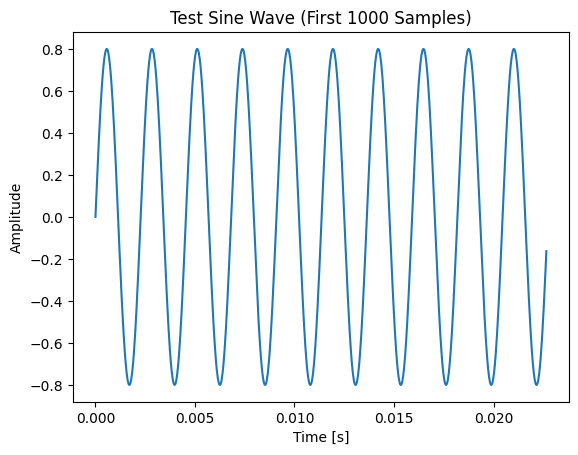

Pitch values (Hz):
[  0.       0.     440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054 440.0054
 440.0054 440.0054 440.0054 440.

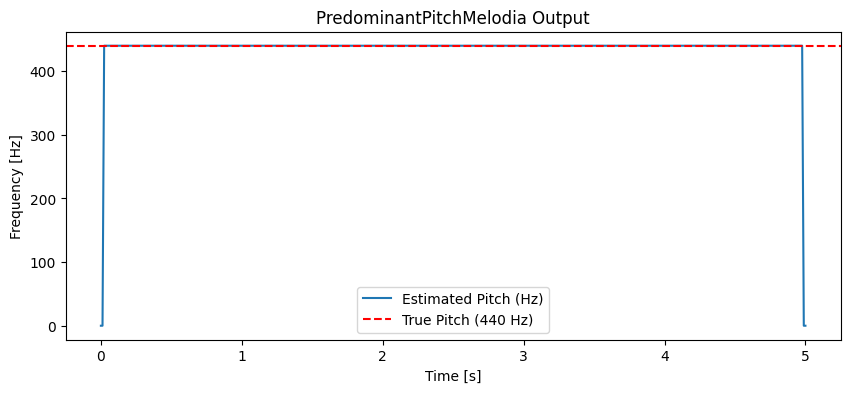

In [6]:
import numpy as np
import essentia.standard as es
import matplotlib.pyplot as plt

# Parameters for the test tone.
duration = 5.0           # seconds
sample_rate = 44100      # Hz
frequency = 440.0        # A4 in Hz
amplitude = 0.8

# Generate a sine wave.
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
sine_wave = amplitude * np.sin(2 * np.pi * frequency * t).astype(np.float32)

# Plot a short segment of the sine wave.
plt.plot(t[:1000], sine_wave[:1000])
plt.title("Test Sine Wave (First 1000 Samples)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.show()

# Use Essentia's PredominantPitchMelodia on the generated sine wave.
# We choose a frameSize and hopSize suitable for a steady tone.
frame_size = 2048
hop_size = 512

# Initialize the pitch extractor.
pitch_extractor = es.PredominantPitchMelodia(frameSize=frame_size,
                                             hopSize=hop_size,
                                             sampleRate=sample_rate)

# Process the entire sine wave.
pitch_values, pitch_confidences = pitch_extractor(sine_wave)

# Print out the results.
print("Pitch values (Hz):")
print(pitch_values)
print("Pitch confidences:")
print(pitch_confidences)

# Optionally, plot the extracted pitch contour.
times = np.linspace(0, duration, len(pitch_values))
plt.figure(figsize=(10, 4))
plt.plot(times, pitch_values, label="Estimated Pitch (Hz)")
plt.axhline(frequency, color='r', linestyle='--', label="True Pitch (440 Hz)")
plt.title("PredominantPitchMelodia Output")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.legend()
plt.show()

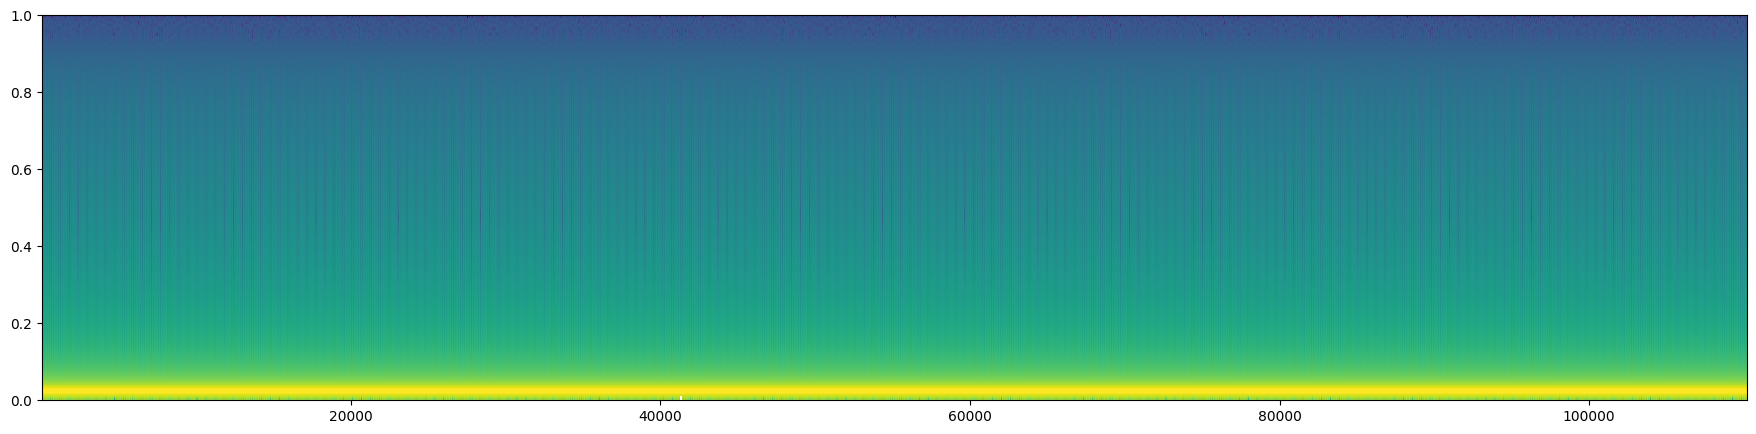

In [7]:
from hum import disp_wf

disp_wf(sine_wave)

# Resources

* Hand gesture recognizer: https://storage.googleapis.com/mediapipe-models/gesture_recognizer/gesture_recognizer/float16/1/gesture_recognizer.task

# Reading a recorded theremin session

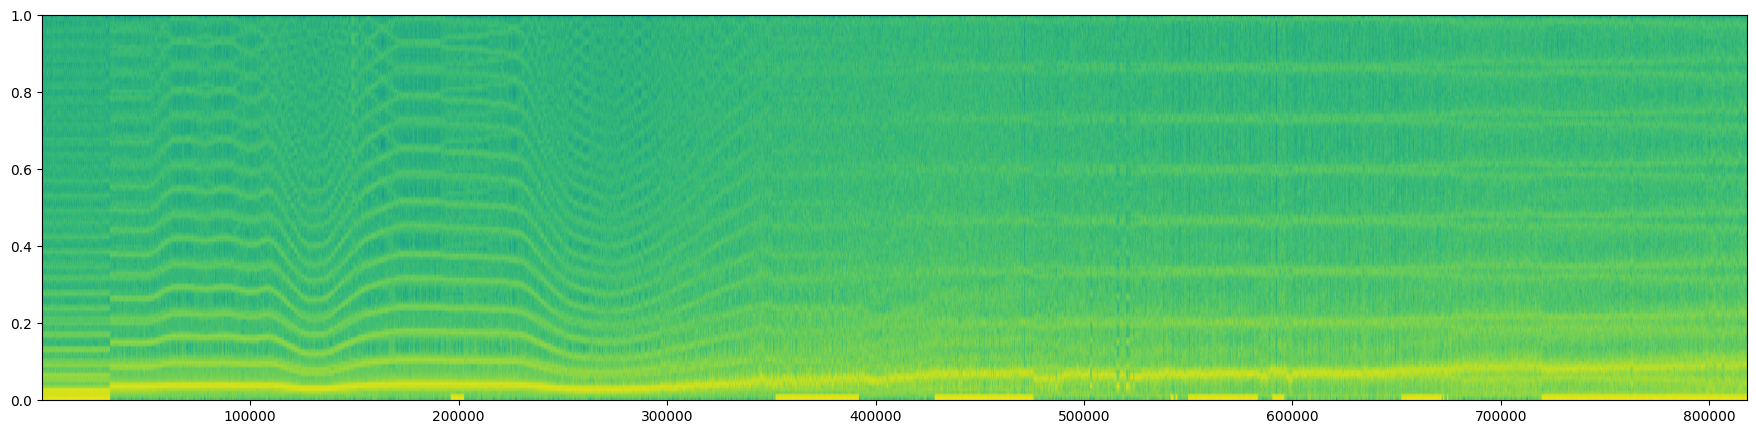

In [13]:
def audio_channels_arrays_of_pcm(pcm, n_channels=2):
    from recode import decode_pcm_bytes
    from pathlib import Path
    import os
    import numpy as np

    if isinstance(pcm, str):
        pcm_filepath = pcm
        pcm = Path(pcm_filepath).expanduser().absolute().read_bytes()

    assert isinstance(pcm, bytes), "pcm must be a bytes object or a path to a file"

    lists_of_channel_value_pairs = decode_pcm_bytes(pcm, n_channels=n_channels)

    return list(map(np.array, zip(*lists_of_channel_value_pairs)))


pcm_filepath = '~/Dropbox/py/proj/t/theremin/misc/theremin_audio.pcm'
channel_1, channel_2 = audio_channels_arrays_of_pcm(pcm_filepath)

import hum

# channel_1 is a lot of hiss. channel_2 is the actual signal
hum.disp_wf(channel_2)

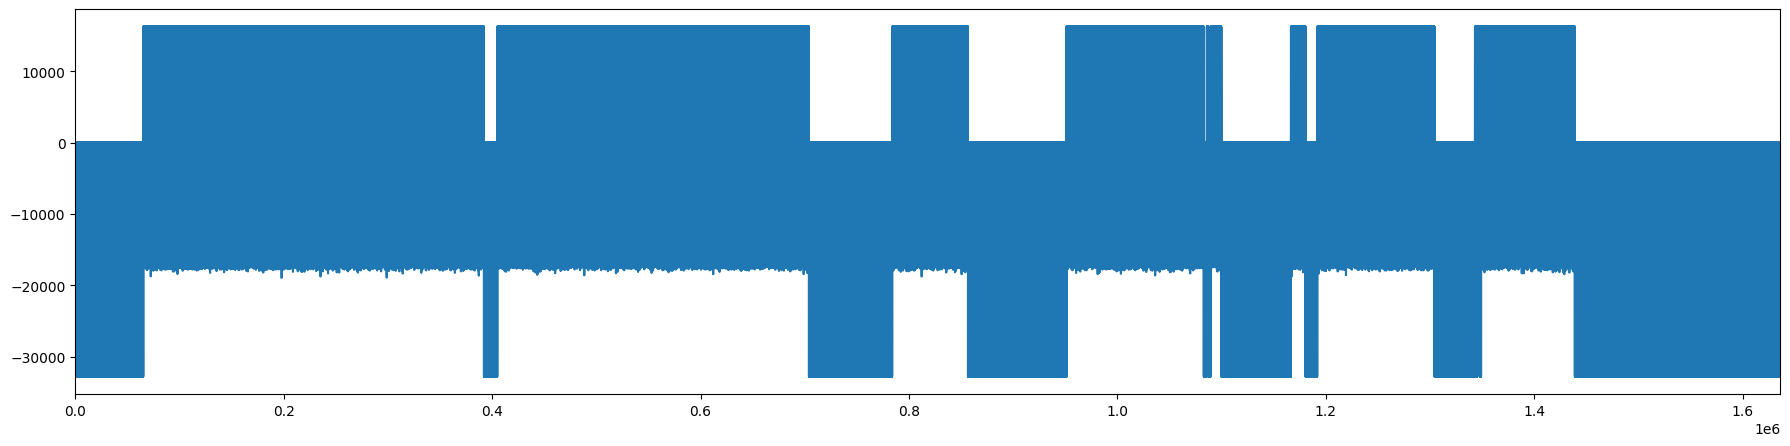

In [8]:
hum.plot_wf(channel_2)

# Getting content for AI

## Making the mediapipe guide

In [1]:
import scraped

url = 'https://ai.google.dev/edge/mediapipe/solutions/guide'
scraped.markdown_of_site(
    url, depth=2, 
    save_filepath='/Users/thorwhalen/Dropbox/_odata/ai_contexts/documentation/mediapipe_guide.md'
)

'/Users/thorwhalen/Dropbox/_odata/ai_contexts/documentation/mediapipe_guide.md'

In [1]:
set({'openness': 0.13809361222165162, 'index_finger_extension_angle1': 69.02349616887912, 'index_finger_extension_angle2': 141.72146681252184, 'thumb_index_distance': 0.13453158385770417, 'is_pinching': False})

{'index_finger_extension_angle1',
 'index_finger_extension_angle2',
 'is_pinching',
 'openness',
 'thumb_index_distance'}

## Getting content from github

In [ ]:
from hubcap import repo_text_aggregate
from pathlib import Path

string = repo_text_aggregate('')
Path('')

# Scrap

## SigTo types

In [51]:
from pyo import PyoObject, SigTo
from typing import Union
SigToValueType = Union[float, int, PyoObject]
_sigto_value_types = SigToValueType.__args__
_sigto_value_types

(float, int, pyo.lib._core.PyoObject)

In [53]:
# import module from filepath
from importlib.util import spec_from_file_location, module_from_spec
import importlib.util
import os
import sys
import importlib
import importlib.util

filepath = '/Users/thorwhalen/Dropbox/py/proj/t/theremin/misc/_12_wrist_lines_w_pyo.py'
spec = importlib.util.spec_from_file_location("module.name", filepath)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)
# Now you can use the module

In [99]:
theremin_knobs = module.theremin_knobs
theremin_synth = module.theremin_synth
sine_synth = module.sine_synth

from i2 import Sig 

Sig(theremin_synth)

<Sig (freq=440, volume=0.5, attack=0.01, release=0.1, vibrato_rate=5, vibrato_depth=5, *, waveform='sine')>

In [17]:
from pyo import * 
from hum.pyo_util import knob_params, knob_exclude

# @knob_exclude('waveform')
@knob_params('freq', 'volume')
def theremin_synth(
    freq=440,
    volume=0.5,
    attack=0.01,
    release=0.1,
    vibrato_rate=5,
    vibrato_depth=5,
    *,
    waveform='sine',
):
    """
    Emulates a classic theremin sound.

    Parameters:
    - freq (float): Base frequency in Hz.
    - volume (float): Output volume (0 to 1).
    - waveform (str): Waveform type ('sine', 'triangle', 'square').
    - attack (float): Attack time in seconds.
    - release (float): Release time in seconds.
    - vibrato_rate (float): Vibrato frequency in Hz.
    - vibrato_depth (float): Vibrato depth in Hz.

    Returns:
    - PyoObject: The resulting audio signal.
    """
    # Select waveform
    waveforms = {
        'sine': Sine,
        'triangle': lambda freq, mul: LFO(freq=freq, type=3, mul=mul),
        'square': lambda freq, mul: LFO(freq=freq, type=1, mul=mul),
    }
    wave_class = waveforms.get(waveform, Sine)

    # Vibrato modulation
    vibrato = Sine(freq=vibrato_rate, mul=vibrato_depth)

    # Envelope
    env = Adsr(
        attack=attack, decay=0.1, sustain=0.8, release=release, dur=0, mul=volume
    )
    env.play()
    # Oscillator with vibrato
    osc = wave_class(freq=freq + vibrato, mul=env)

    return osc



def sine_synth(freq=440, volume=1, **kwargs):
    return Sine(freq=freq, mul=volume).out()


def supersaw_synth(freq=440, volume=1, detune=0.01, n_voices=7, **kwargs):
    voices = [
        LFO(
            freq=freq * (1 + detune * (i - n_voices // 2)),
            type=5,
            mul=volume / n_voices,
        )
        for i in range(n_voices)
    ]
    return sum(voices)



from hum.pyo_util import Synth, knob_params

# synth = Synth(sine_synth)
# synth = Synth(supersaw_synth, knob_exclude=['n_voices'])

# synth_func = knob_params('volume', 'freq', 'detune')(supersaw_synth)
# synth = Synth(synth_func, knob_exclude=['n_voices'])

# synth = Synth(theremin_synth, knob_params=['freq', 'volume'], knob_exclude=['waveform'])

synth = Synth(theremin_synth)

with synth:
    time.sleep(1)
    synth.knobs.update({'waveform': 'square'})
    time.sleep(2)
    synth.knobs.update({'freq': 1000})
    time.sleep(1)
    synth.knobs.update({'freq': 500})
    time.sleep(1)
    synth.knobs.update({'volume': {'value': 0, 'time': 0.5}})
    time.sleep(0.5)


synth._initial_knob_params


{'freq': < Instance of SigTo class >,
 'volume': < Instance of SigTo class >,
 'attack': 0.01,
 'release': 0.1,
 'vibrato_rate': 5,
 'vibrato_depth': 5,
 'waveform': 'sine'}

In [11]:
from pyo import *

try:
    # Start server
    s = Server().boot()
    s.start()

    # Parameters
    freq = 440
    volume = 0.3

    # Create all possible waveforms at once
    sine = Sine(freq=freq)
    triangle = LFO(freq=freq, type=2)
    square = LFO(freq=freq, type=1)

    # Gains controlled by SigTo objects
    sine_gain = SigTo(value=1.0, time=0.5)     # Start with sine at full volume
    triangle_gain = SigTo(value=0.0, time=0.5) # Other waveforms at zero
    square_gain = SigTo(value=0.0, time=0.5)

    # Final mix
    output = (sine * sine_gain + triangle * triangle_gain + square * square_gain) * volume
    output.out()

    # --- Control function ---

    def switch_waveform(target_waveform):
        print(f"Switching to", target_waveform)
        gains = {
            'sine': sine_gain,
            'triangle': triangle_gain,
            'square': square_gain,
        }
        for name, gain in gains.items():
            gain.time = 0.2  # <--- set fade time first!
            if name == target_waveform:
                gain.setValue(1.0)
            else:
                gain.setValue(0.0)

    # Now you can call:
    time.sleep(2)
    switch_waveform('triangle')
    time.sleep(2)
    switch_waveform('square')
    time.sleep(2)
    switch_waveform('sine')
    time.sleep(2)
finally: 
    # Stop server
    s.stop()
    s.shutdown()


Pyo warning: Portaudio input device `MacBook Pro Microphone` has fewer channels (1) than requested (2).
Switching to triangle
Switching to square
Switching to sine


In [ ]:
from pyo import *
from hum.pyo_util import Synth, knob_params, knob_exclude

def sine_synth(freq=440, volume=1, **kwargs):
    return Sine(freq=freq, mul=volume)

def supersaw_synth(freq=440, volume=1, detune=0.01, n_voices=7, **kwargs):
    voices = [
        LFO(
            freq=freq * (1 + detune * (i - n_voices // 2)),
            type=5,
            mul=volume / n_voices,
        )
        for i in range(n_voices)
    ]
    return sum(voices)


synth = Synth(supersaw_synth, dials=['volume', 'freq', 'detune'], settings=['n_voices'])


with synth:
    time.sleep(1)
    synth.knobs.update({'freq': 1000})
    time.sleep(1)
    synth.knobs.update({'freq': 500})
    time.sleep(1)
    synth.knobs.update({'n_voices': 1})
    time.sleep(1)


In [ ]:
from pyo import *
from hum.pyo_util import Synth, knob_params, knob_exclude

def supersaw_synth(freq=440, volume=1, detune=0.01, n_voices=7, **kwargs):
    voices = [
        LFO(
            freq=freq * (1 + detune * (i - n_voices // 2)),
            type=5,
            mul=volume / n_voices,
        )
        for i in range(n_voices)
    ]
    return sum(voices)


synth = Synth(supersaw_synth, dials=['volume', 'freq', 'detune'], settings=['n_voices'])

with synth:
    time.sleep(1)
    synth.update({'freq': 1000})         # Live update
    time.sleep(1)
    synth.update({'n_voices': 3})         # Triggers rebuild
    time.sleep(1)
    synth.update({'freq': 400, 'n_voices': 5})  # freq updated live, n_voices triggers rebuild
    time.sleep(1)

In [10]:
t = synth.get_recording()
t

[(0.0,
  {'freq': {'value': 440, 'time': 0.025, 'mul': 1, 'add': 0},
   'volume': {'value': 1, 'time': 0.025, 'mul': 1, 'add': 0},
   'detune': {'value': 0.01, 'time': 0.025, 'mul': 1, 'add': 0},
   'n_voices': 7}),
 (1.000636100769043, {'freq': 1000}),
 (3.012451171875, {'freq': 400}),
 (4.021373987197876, {})]

In [11]:
synth.play_events(t)

TypeError: cannot convert dictionary update sequence element #0 to a sequence

In [3]:
with synth:
    time.sleep(1)
    synth.knobs.update({'volume': 0.5})
    time.sleep(1)
    synth.knobs.update({'volume': {'value': 0, 'time': 0.5}})
    time.sleep(0.5)


In [5]:

# Dual sine oscillator with LFO-controlled lowpass filter
def dual_osc_graph(freq1=220, freq2=330, amp=0.3, lfo_freq=0.5):
    osc1 = Sine(freq=freq1)
    osc2 = Sine(freq=freq2)
    blend = Mix([osc1, osc2], voices=2) * amp
    lfo = Sine(freq=lfo_freq).range(400, 2000)
    return ButLP(blend, freq=lfo)

synth = Synth(dual_osc_graph)
# 👂 Frequency shifts with LFO sweeping filter
with synth:
    time.sleep(0.5)
    synth.knobs['freq1'] = 440
    time.sleep(1)
    synth.knobs['freq2'] = SigTo(550, time=0.5)  # Smooth shift
    time.sleep(0.5)
    synth.knobs.update(dict(freq1={'value': 880, 'time': 0.1}, freq2=1100))
    time.sleep(1)


In [98]:
from hum.pyo_util import Synth

synth = Synth(sine_synth)

with synth:
    time.sleep(1)
    synth.knobs.update({'volume': 0.5})
    synth.knobs.update({'volume': {'value': 0, 'time': 0.5}})
    time.sleep(0.5)

synth._initial_knob_params

{'freq': < Instance of SigTo class >, 'volume': < Instance of SigTo class >}

In [86]:
import time

with synth:
    time.sleep(1)
    synth.knobs['freq'] = 200
    time.sleep(1)
    synth.knobs['volume'] = {'value': 0, 'time': 0.2}
    time.sleep(1)


In [ ]:
from pyo import * 

def dual_osc_graph(freq1=220, freq2=330, amp=0.3, lfo_freq=0.5):
    osc1 = Sine(freq=freq1)
    osc2 = Sine(freq=freq2)
    blend = Mix([osc1, osc2], voices=2) * amp
    lfo = Sine(freq=lfo_freq).range(400, 2000)
    return ButLP(blend, freq=lfo)

synth = Synth(sine_synth, nchnls=2)
# 👂 Frequency shifts with LFO sweeping filter
with synth:
    time.sleep(0.5)
    synth.knobs['freq'] = 440
    time.sleep(1)

## Slabs

I0000 00:00:1755513074.291161 2846519 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1 Max
I0000 00:00:1755513074.292795 2846519 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1 Max
W0000 00:00:1755513074.293037 2846519 gesture_recognizer_graph.cc:129] Hand Gesture Recognizer contains CPU only ops. Sets HandGestureRecognizerGraph acceleration to Xnnpack.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
I0000 00:00:1755513074.293891 2846519 hand_gesture_recognizer_graph.cc:250] Custom gesture classifier is not defined.
W0000 00:00:1755513074.298516 2846705 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755513074.302949 2846718 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755513074.304997 2846705 inference_feedbac

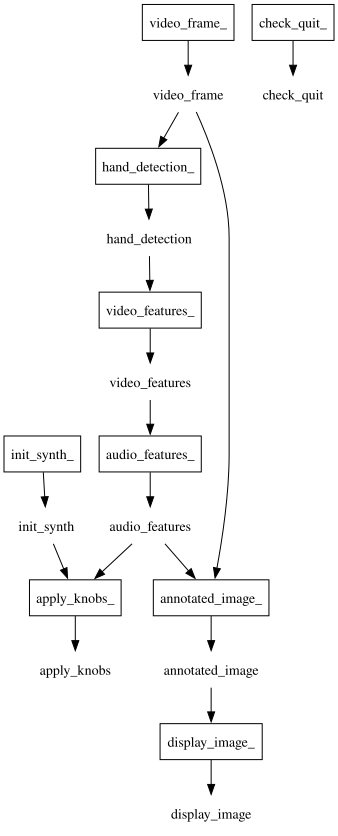

In [1]:
from theremin.scrap.theremin_w_slabs import create_theremin_slabs

s = create_theremin_slabs(None)

s.dot_digraph()

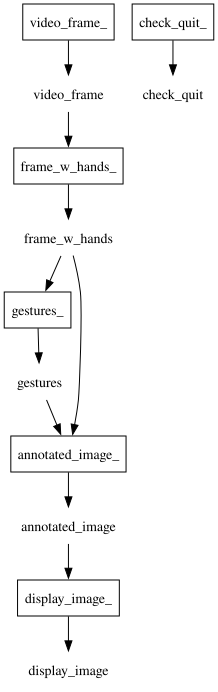

In [ ]:
from theremin.scrap.example_w_slabs import create_slabs_instance
s = create_slabs_instance(None, None, None)

s.dot_digraph()

# Antescofo

In [12]:
import scraped 
scraped.util.DFLT_ROOTDIR

'/Users/thorwhalen/.config/scraped/data'

In [ ]:
from aubio import source, tempo


# Scrap: Keyboard Theremin and MIDI/SoundFont

In [ ]:
import enum
from typing import Dict


class Controls(enum.Enum):
    INCREASE_PITCH = 'increase_pitch'
    DECREASE_PITCH = 'decrease_pitch'
    INCREASE_VOLUME = 'increase_volume'
    DECREASE_VOLUME = 'decrease_volume'


KLAZ_CONTROL_KEYS = {
    'k': Controls.INCREASE_PITCH,
    'l': Controls.DECREASE_PITCH,
    'a': Controls.INCREASE_VOLUME,
    'z': Controls.DECREASE_VOLUME,
}

ARROW_KEYS = {
    'up': Controls.INCREASE_PITCH,
    'down': Controls.DECREASE_PITCH,
    'right': Controls.INCREASE_VOLUME,
    'left': Controls.DECREASE_VOLUME,
}

WASD_KEYS = {
    'a': Controls.INCREASE_PITCH,
    'd': Controls.DECREASE_PITCH,
    'w': Controls.INCREASE_VOLUME,
    's': Controls.DECREASE_VOLUME,
}


def keyboard_theremin(
    pitches,
    volumes,
    instrument,
    control_keys: Dict[str, Controls]=KLAZ_CONTROL_KEYS,
    validation_warning: bool=True,
    interrupt_key: str='q',
):
    """
    Launch a keyboard theremin.
    This will launch a process that will play sound continuously, decreasing or 
    increasing it's pitch when, respectively.

    :param pitches: list of pitches to play. The order of the pitches will determin
        what pitch is played when the Controls.INCREASE_PITCH or Controls.DECREASE_PITCH
        is pressed. Unless disabled, a warning is raised if the pitches are not sorted.
    :param volumes: list of volumes to play. The order of the volumes will determine
        what volume is played when the Controls.INCREASE_VOLUME or Controls.DECREASE_VOLUME
        is pressed. Unless disabled, a warning is raised if the volumes are not sorted.
    :param instrument: the instrument to play the sound with.
    :param control_keys: a dictionary mapping keys to Controls.
    :param validation_warning: whether to raise a warning if the pitches or volumes are not sorted.
    :param interrupt_key: the key that will interrupt the process.

    Extra information:
    
    If an increase of pitch or volume would go beyond the list of pitches or volumes,
    the last pitch or volume is played.

    """


In [5]:
import mido

print(mido.get_output_names())

[]


In [ ]:
import time
import fluidsynth

def play_note_with_fluidsynth(note, velocity, duration, soundfont):
    # Initialize FluidSynth
    fs = fluidsynth.Synth()
    fs.start()

    # Load the soundfont
    sfid = fs.sfload(soundfont)
    fs.program_select(0, sfid, 0, 0)

    # Play the note
    fs.noteon(0, note, velocity)

    # Wait for the specified duration
    time.sleep(duration)

    # Stop the note
    fs.noteoff(0, note)

    # Cleanup
    fs.delete()

# Example usage
note = 60  # Middle C
velocity = 64  # Standard velocity
duration = 1.0  # 1 second
soundfont = "/Users/thorwhalen/Dropbox/Media/soundfonts/Arachno SoundFont - Version 1.0.sf2"

play_note_with_fluidsynth(note, velocity, duration, soundfont)

# Trying to scrape a grok shared chat to get the search results

In [ ]:
import asyncio
from playwright.async_api import async_playwright

url = 'https://grok.com/share/bGVnYWN5_3a4e7a99-ecec-4862-935b-55c8a71d03fd'

async def get_grok_chat_html(url):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True) # Set headless=True for background execution
        page = await browser.new_page()
        await page.goto(url)

        # --- IMPORTANT: Adjust these waiting strategies ---
        # You need to find a robust way to know the page has fully loaded its content.
        # Option 1: Wait for a specific element that exists only when the chat is loaded.
        # You'll need to inspect the Grok page's HTML to find this.
        try:
            # Example: Wait for a div with a class like 'chat-messages-container'
            # or a specific message element.
            await page.wait_for_selector('div[data-testid="chat-message"]', timeout=15000)
            # Try waiting for an element you know is loaded once the content is there.
            # I'm using a common pattern for chat messages, but verify this on the actual Grok page.
        except Exception as e:
            print(f"Warning: Did not find expected chat content element within timeout: {e}")
            print("Proceeding anyway, but content might be incomplete.")

        # Option 2: Wait for network idle. This often works well for dynamic content.
        # await page.wait_for_load_state("networkidle")


        html_content = await page.content()
        await browser.close()
        return html_content

# --- This is how you run it in a Jupyter Notebook cell: ---
html = await get_grok_chat_html(url)
print(html[:1000]) # Print first 1000 characters to avoid flooding output